In [1]:
# código para instalar o pacote necessário
!pip install kmodes

In [2]:
# código para carregar os pacotes necessários
import requests
import pandas as pd
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree

In [3]:
# código para carregar o 'tidy_data.csv'
df = pd.read_csv('/content/tidy_data.csv', sep=";", decimal=",", index_col=0)

# código para exibir as primeiras linhas do banco de dados
df.head()

,indicator,code,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper,eiu,prs,wmo,scalemean,scalesd,extreme_event
1,cc,AGO,-0.012749,-0.035021,4,-2.190789,-0.537634,-0.146627,0.0,-0.166667,0.000,0.006610,0.941908,0
2,cc,AGO,-0.017064,0.023130,4,1.024007,0.000000,0.386847,0.0,0.000000,0.000,0.004617,0.932170,0
3,cc,AGO,0.042022,-0.037853,4,-0.574131,0.000000,-1.733648,0.0,0.000000,0.000,-0.007821,0.933826,0
4,cc,AGO,-0.179971,-0.021847,6,-2.645503,0.000000,-14.285714,0.0,0.000000,0.000,-0.035608,0.929151,0
5,cc,AGO,-0.042106,-0.005851,8,0.620325,0.000000,1.660280,0.0,0.000000,0.125,-0.017960,0.922920,0


In [4]:
# código para criar a nova coluna 'quantil' para cada 'indicator'
df['quantil'] = df.groupby('indicator')['estimate'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

In [5]:
# código para exibir as primeiras linhas do banco de dados
df.head()

,indicator,code,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper,eiu,prs,wmo,scalemean,scalesd,extreme_event,quantil
1,cc,AGO,-0.012749,-0.035021,4,-2.190789,-0.537634,-0.146627,0.0,-0.166667,0.000,0.006610,0.941908,0,2
2,cc,AGO,-0.017064,0.023130,4,1.024007,0.000000,0.386847,0.0,0.000000,0.000,0.004617,0.932170,0,2
3,cc,AGO,0.042022,-0.037853,4,-0.574131,0.000000,-1.733648,0.0,0.000000,0.000,-0.007821,0.933826,0,3
4,cc,AGO,-0.179971,-0.021847,6,-2.645503,0.000000,-14.285714,0.0,0.000000,0.000,-0.035608,0.929151,0,2
5,cc,AGO,-0.042106,-0.005851,8,0.620325,0.000000,1.660280,0.0,0.000000,0.125,-0.017960,0.922920,0,2


In [6]:
# código para converter as colunas para tipo Categorical
df['code'] = df['code'].astype('category')
df['quantil'] = df['quantil'].astype('category')
df['extreme_event'] = df['extreme_event'].astype('category')
df['indicator'] = df['indicator'].astype('category')

In [7]:
# código para verificar os tipos das colunas
print(df.dtypes)

indicator        category
code             category
estimate          float64
stddev            float64
nsource             int64
pctrank           float64
pctranklower      float64
pctrankupper      float64
eiu               float64
prs               float64
wmo               float64
scalemean         float64
scalesd           float64
extreme_event    category
quantil          category
dtype: object


In [8]:
# código para filtrar o banco de dados
df_filtered = df[['indicator', 'code', 'quantil']]

In [9]:
# código para definir o intervalo de valores de k a serem testados
k_range = range(1, 11)
costs = []

# código para iterar os diferentes valores de k
for k in k_range:
    km = KModes(n_clusters=k, init='Huang', n_init=10, verbose=1)
    km.fit(df_filtered)
    costs.append(km.cost_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 6, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 7, iteration: 1/100, moves: 0, cost: 45689.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 8, iteration:

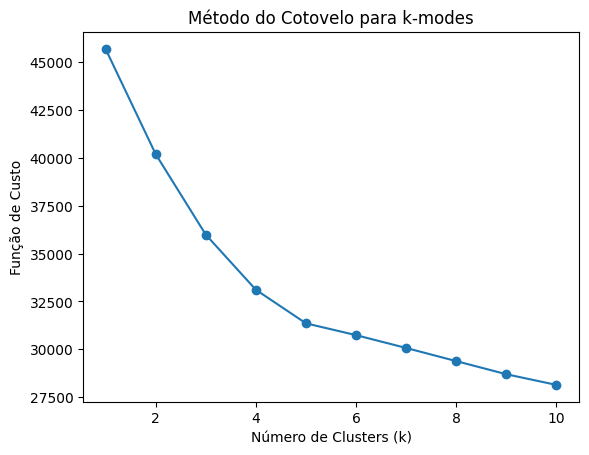

In [10]:
# código para plotar o gráfico do método do cotovelo
plt.plot(k_range, costs, marker='o')
plt.title('Método do Cotovelo para k-modes')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Função de Custo')
plt.show()

In [11]:
# código para aplicar o k-modes com o número adequado de clusters
km = KModes(n_clusters=4, init='Huang', n_init=10, verbose=1)
km.fit(df_filtered)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 2231, cost: 33175.0
Run 1, iteration: 2/100, moves: 1829, cost: 33105.0
Run 1, iteration: 3/100, moves: 61, cost: 33105.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 34969.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 1861, cost: 35337.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 47, cost: 34093.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 2477, cost: 33628.0
Run 5, iteration: 2/100, moves: 175, cost: 33628.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 6, iteration: 1/100, moves: 142, cost: 33570.0
Init: initializing centroids
Init: initializing clusters
Star

KModes(init='Huang', n_clusters=4, verbose=1)

In [12]:
# código para atribuir os clusters diretamente ao banco de dados
df['cluster'] = km.labels_

# código para exibir as primeiras linhas do banco de dados
df.head()

,indicator,code,estimate,stddev,nsource,pctrank,pctranklower,pctrankupper,eiu,prs,wmo,scalemean,scalesd,extreme_event,quantil,cluster
1,cc,AGO,-0.012749,-0.035021,4,-2.190789,-0.537634,-0.146627,0.0,-0.166667,0.000,0.006610,0.941908,0,2,1
2,cc,AGO,-0.017064,0.023130,4,1.024007,0.000000,0.386847,0.0,0.000000,0.000,0.004617,0.932170,0,2,1
3,cc,AGO,0.042022,-0.037853,4,-0.574131,0.000000,-1.733648,0.0,0.000000,0.000,-0.007821,0.933826,0,3,0
4,cc,AGO,-0.179971,-0.021847,6,-2.645503,0.000000,-14.285714,0.0,0.000000,0.000,-0.035608,0.929151,0,2,1
5,cc,AGO,-0.042106,-0.005851,8,0.620325,0.000000,1.660280,0.0,0.000000,0.125,-0.017960,0.922920,0,2,1


In [13]:
# código para aplicar Label Encoding nas colunas categóricas
encoder = LabelEncoder()

# código para aplicar LabelEncoder em cada coluna categórica
df_filtered['indicator'] = encoder.fit_transform(df_filtered['indicator'])
df_filtered['code'] = encoder.fit_transform(df_filtered['code'])
df_filtered['quantil'] = encoder.fit_transform(df_filtered['quantil'])

<ipython-input-13-d6965c724208>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['indicator'] = encoder.fit_transform(df_filtered['indicator'])
<ipython-input-13-d6965c724208>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['code'] = encoder.fit_transform(df_filtered['code'])
<ipython-input-13-d6965c724208>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [33]:
# código para definir a variável dependente (target) e as variáveis independentes (features)
features = df_filtered
target = df['cluster']

In [34]:
# código para criar o modelo CART para classificação
clf = DecisionTreeClassifier(random_state = 42, max_depth = 4)
clf.fit(features, target)

DecisionTreeClassifier(max_depth=4, random_state=42)

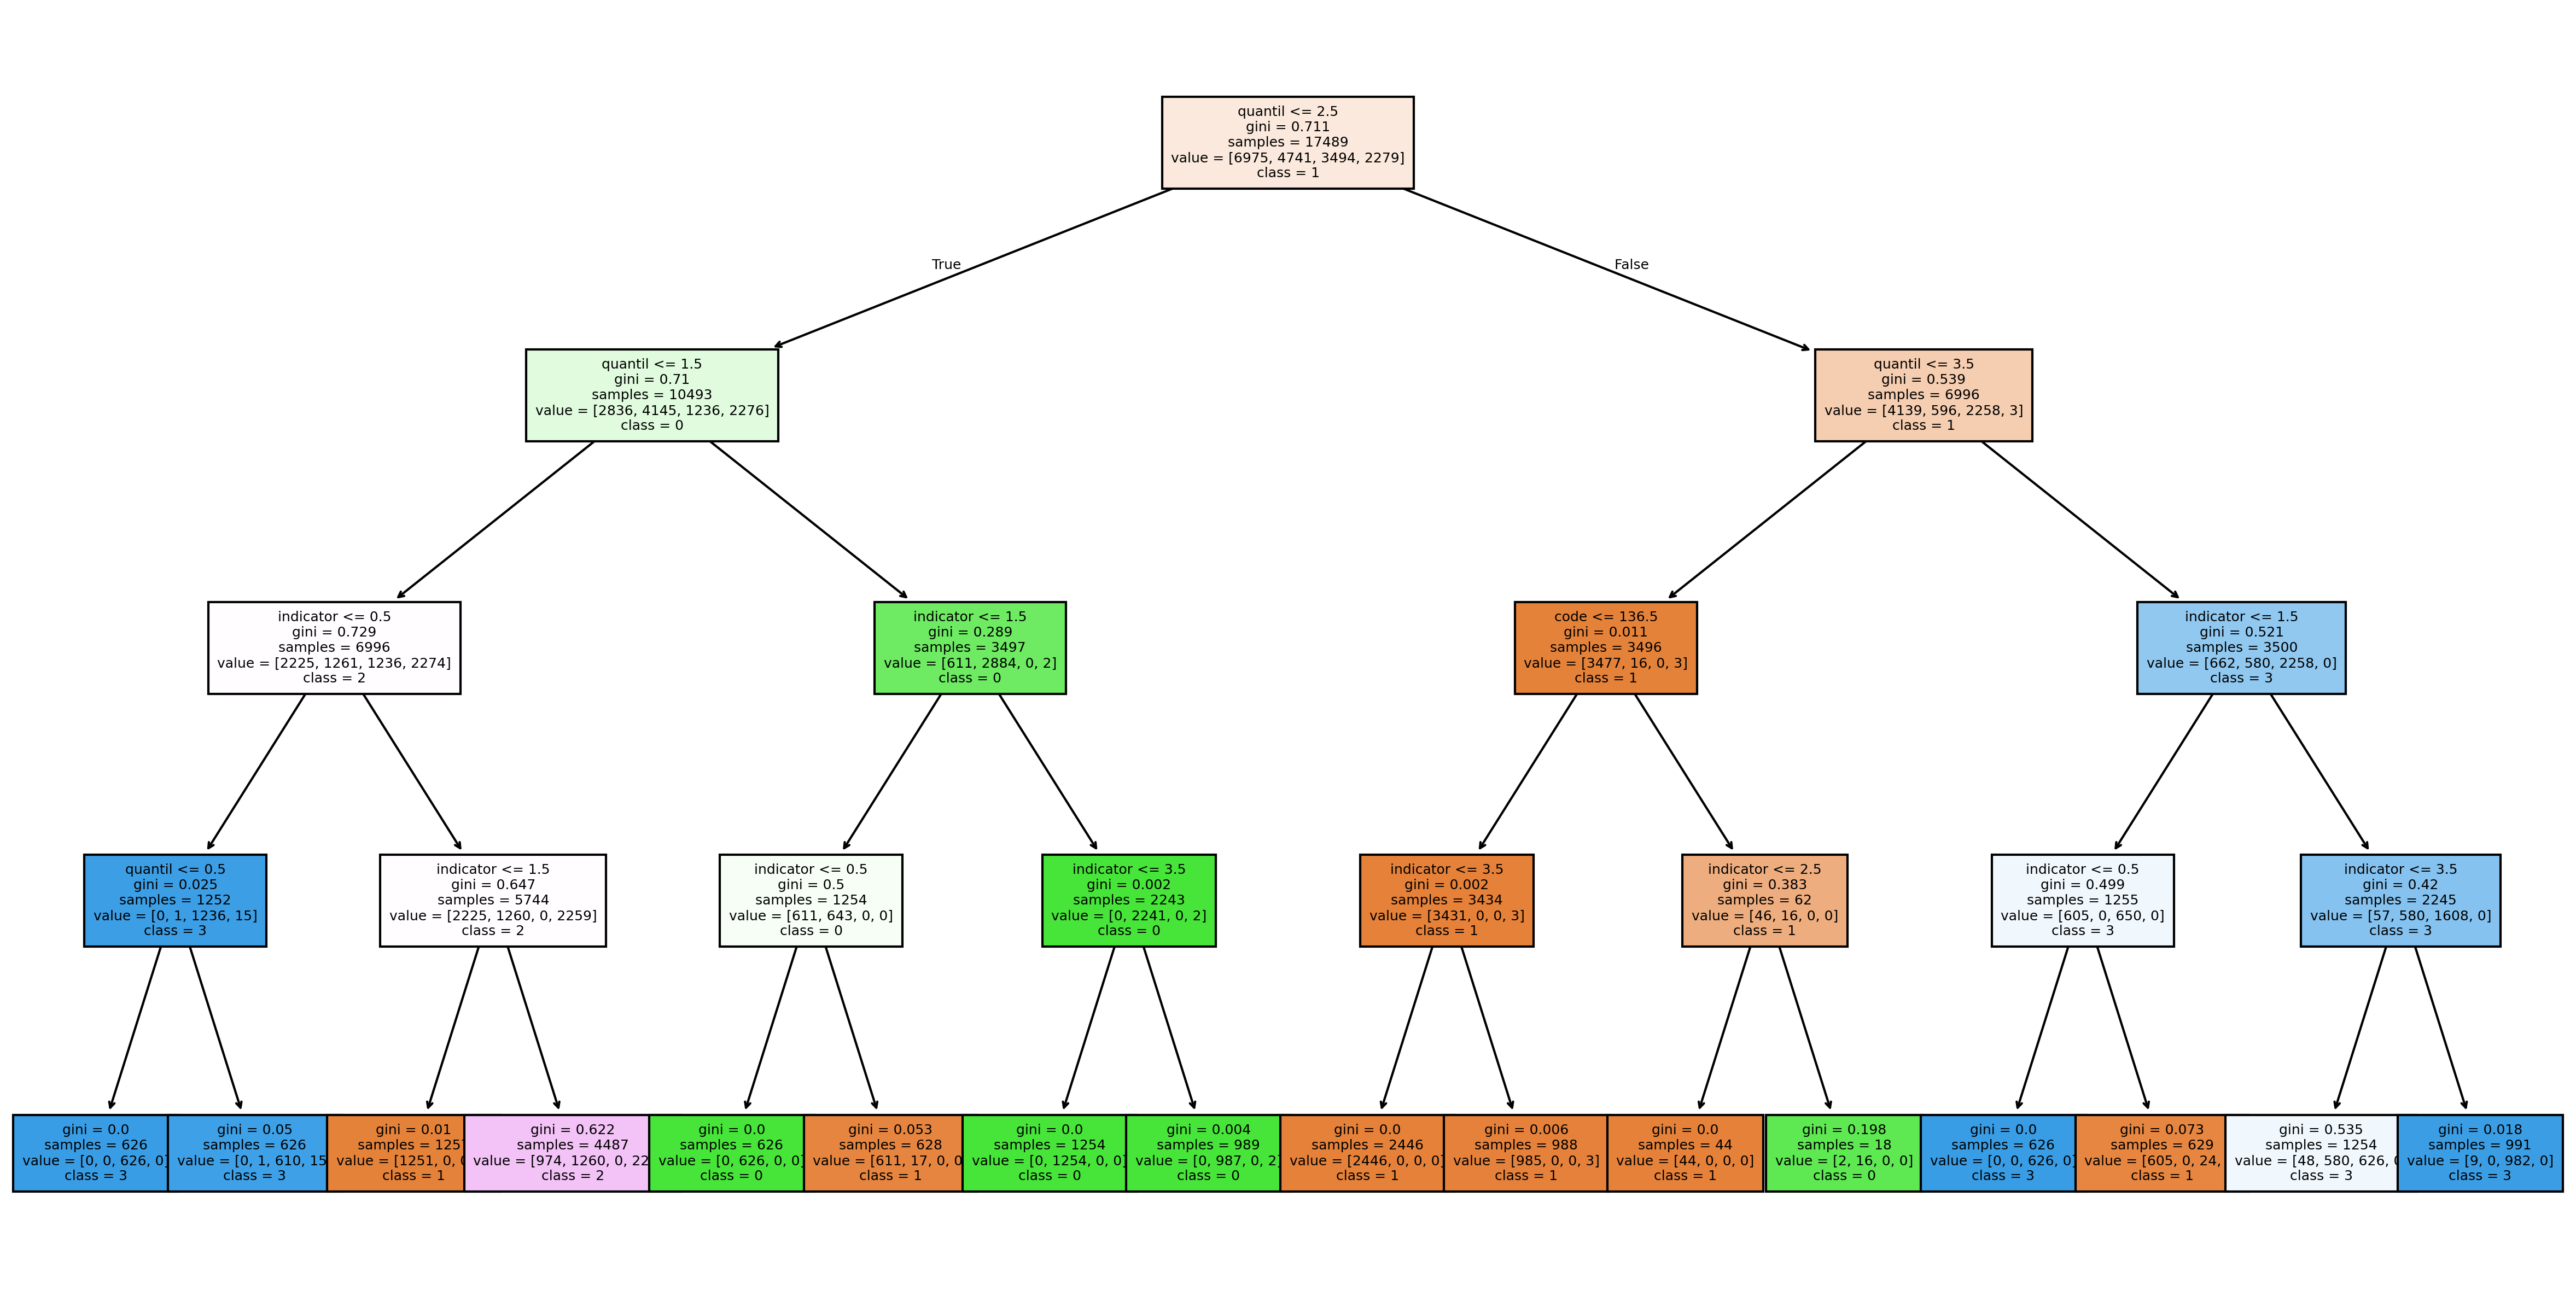

In [35]:
# código para visualizar a árvore de decisão treinada
plt.figure(figsize=(20, 10), dpi=300)
tree.plot_tree(clf, filled=True, feature_names=features.columns, class_names = [str(c) for c in target.unique()], fontsize=6)
plt.savefig('arvore_decisao.png', dpi=300)
plt.show()

In [38]:
# código para obter as importâncias das variáveis
importances = clf.feature_importances_

# código para visualizar a importância das variáveis em uma base de dados
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': importances
})

# código para ordenar as variáveis pela importância
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# código para exibir as variáveis ordenadas pela importância
print(importance_df)

     Feature  Importance
2    quantil    0.505289
0  indicator    0.493794
1       code    0.000917
